In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t, s = sp.symbols("t s")

from ass_ import *
a_2 = Ass_2()

## 3a

<>:84: SyntaxWarning: invalid escape sequence '\k'
<>:84: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_7970/3238779109.py:84: SyntaxWarning: invalid escape sequence '\k'
  plt.title("Comparison of Curvature $\kappa(t)$")



========== Analysis for Curve (i) ==========
--- Evaluated at t = 0 ---
Tangent (T)   : [0.5774 0.5774 0.5774]
Normal (N)    : [-0.7071  0.7071  0.    ]
Binormal (B)  : [-0.4082 -0.4082  0.8165]
Curvature (κ) : [0.4714]
Torsion (τ)   : [0.3333]

========== Analysis for Curve (ii) ==========
--- Evaluated at t = 1.5707963267948966 ---
Tangent (T)   : [-1.  0.  0.]
Normal (N)    : [-0. -1.  0.]
Binormal (B)  : [0. 0. 1.]
Curvature (κ) : [0.75]
Torsion (τ)   : [0.]


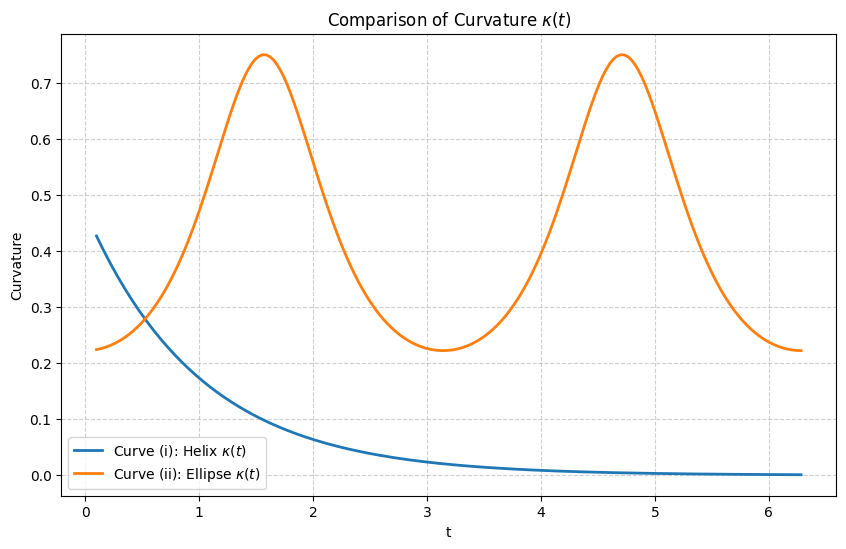

In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

class FrenetSerretSolver:
    def __init__(self):
        self.t = sp.symbols('t', real=True)

    def compute_frame(self, r_vec, t_val=None, label="Curve"):
        # 1. Derivatives
        r = sp.Matrix(r_vec)
        v = r.diff(self.t)      # r'
        a = v.diff(self.t)      # r''
        jerk = a.diff(self.t)   # r'''

        # 2. Vector Operations
        # Cross product of v and a (Crucial for B, Kappa, Tau)
        v_cross_a = v.cross(a)
        
        # Norms (Magnitudes)
        speed = sp.simplify(v.norm())            # |r'|
        norm_v_x_a = sp.simplify(v_cross_a.norm()) # |r' x r''|
        
        # 3. Compute T, N, B, Kappa, Tau using Analytical Formulas
        
        # Curvature formula: |r' x r''| / |r'|^3
        kappa = sp.simplify(norm_v_x_a / (speed**3))
        
        # Torsion formula: ((r' x r'') . r''') / |r' x r''|^2
        numerator_tau = v_cross_a.dot(jerk)
        tau = sp.simplify(numerator_tau / (norm_v_x_a**2))

        # Tangent: r' / |r'|
        T = sp.simplify(v / speed)
        
        # Binormal: (r' x r'') / |r' x r''|
        B = sp.simplify(v_cross_a / norm_v_x_a)
        
        # Normal: B x T
        N = sp.simplify(B.cross(T))

        # 4. Output Results
        print(f"\n{'='*10} Analysis for {label} {'='*10}")
        
        if t_val is not None:
            # Helper to evaluate symbolic expression to float
            def val(expr):
                # .evalf() converts to float, then we round
                v = np.array(expr.subs(self.t, t_val)).astype(np.float64).flatten()
                return np.round(v, 4)

            print(f"--- Evaluated at t = {t_val} ---")
            print(f"Tangent (T)   : {val(T)}")
            print(f"Normal (N)    : {val(N)}")
            print(f"Binormal (B)  : {val(B)}")
            print(f"Curvature (κ) : {val(kappa)}")
            print(f"Torsion (τ)   : {val(tau)}")
        
        return kappa

    def plot_graphs(self, k1_expr, k2_expr):
        # Create functions for plotting
        f_k1 = sp.lambdify(self.t, k1_expr, modules='numpy')
        f_k2 = sp.lambdify(self.t, k2_expr, modules='numpy')
        
        t_vals = np.linspace(0.1, 2*np.pi, 200) # Start at 0.1 to avoid potential division by zero
        
        # Calculate values
        # Note: If curvature is constant, lambdify might return a single int/float
        # We use np.full_like to ensure we can plot it against t_vals
        
        y1 = f_k1(t_vals)
        if np.isscalar(y1) or y1.shape == (): y1 = np.full_like(t_vals, y1)
            
        y2 = f_k2(t_vals)
        if np.isscalar(y2) or y2.shape == (): y2 = np.full_like(t_vals, y2)

        # Plotting
        plt.figure(figsize=(10, 6))
        
        plt.plot(t_vals, y1, label=r'Curve (i): Helix $\kappa(t)$', linewidth=2)
        plt.plot(t_vals, y2, label=r'Curve (ii): Ellipse $\kappa(t)$', linewidth=2)
        
        plt.title("Comparison of Curvature $\kappa(t)$")
        plt.xlabel("t")
        plt.ylabel("Curvature")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()

# --- Execution ---
solver = FrenetSerretSolver()
t = solver.t

# Curve 1: r(t) = <e^t cos t, e^t sin t, e^t>
# Evaluate at t = 0
r1 = [sp.exp(t)*sp.cos(t), sp.exp(t)*sp.sin(t), sp.exp(t)]
kappa1 = solver.compute_frame(r1, t_val=0, label="Curve (i)")

# Curve 2: r(t) = <2cos t, 3sin t, 0>
# Evaluate at t = pi/2 (Just as an example point, problem asked for range)
r2 = [2*sp.cos(t), 3*sp.sin(t), 0]
kappa2 = solver.compute_frame(r2, t_val=np.pi/2, label="Curve (ii)")

# Plot
solver.plot_graphs(kappa1, kappa2)

## 3b

In [6]:
import sympy as sp

def verify_pde_properties():
    x, y = sp.symbols('x y', real=True)
    f = y**2 * sp.cos(x - y)

    print(f"Function: f(x,y) = {f}\n")

    # --- 1. Laplace Equation Check ---
    f_xx = sp.diff(f, x, x)
    f_yy = sp.diff(f, y, y)
    laplace_res = sp.simplify(f_xx + f_yy)

    print("--- Laplace Check ---")
    print(f"f_xx + f_yy = {laplace_res}")
    if laplace_res == 0:
        print(">> Satisfies Laplace's Equation.")
    else:
        print(">> DOES NOT satisfy Laplace's Equation.")

    # --- 2. Mixed Partial Identity ---
    f_xy = sp.diff(f, x, y)
    f_yx = sp.diff(f, y, x)
    
    print("\n--- Mixed Partials Check ---")
    print(f"f_xy = {sp.simplify(f_xy)}")
    print(f"f_yx = {sp.simplify(f_yx)}")
    
    if sp.simplify(f_xy - f_yx) == 0:
        print(">> Identity f_xy = f_yx is CONFIRMED.")
    else:
        print(">> Identity FAILED.")

if __name__ == "__main__":
    verify_pde_properties()

Function: f(x,y) = y**2*cos(x - y)

--- Laplace Check ---
f_xx + f_yy = -2*y**2*cos(x - y) + 4*y*sin(x - y) + 2*cos(x - y)
>> DOES NOT satisfy Laplace's Equation.

--- Mixed Partials Check ---
f_xy = y*(y*cos(x - y) - 2*sin(x - y))
f_yx = y*(y*cos(x - y) - 2*sin(x - y))
>> Identity f_xy = f_yx is CONFIRMED.


## 3c

In [7]:
import sympy as sp

def solve_chain_rule():
    theta = sp.symbols('theta', real=True)
    
    # 1. Define x, y, z as functions of theta
    x = sp.cos(theta)
    y = sp.sin(theta)
    z = sp.tan(theta)
    
    # 2. Define w
    # Note: We must define w using the symbolic x, y, z first to show chain rule structure,
    # or substitute them immediately. Here we substitute immediately for exact calculation.
    w = sp.sqrt(x**2 + y**2 + z**2)
    
    # 3. Differentiate w with respect to theta
    dw_dtheta = sp.diff(w, theta)
    
    # 4. Evaluate at pi/4
    result = dw_dtheta.subs(theta, sp.pi/4)
    
    print(f"Symbolic Derivative: {sp.simplify(dw_dtheta)}")
    print(f"Value at pi/4: {result}")

if __name__ == "__main__":
    solve_chain_rule()

Symbolic Derivative: tan(theta)*Abs(cos(theta))/cos(theta)**2
Value at pi/4: sqrt(2)


## 4a

--- Analytical Results ---
Gradient at (-1, 1.5): [-9.  3.]
Directional Derivative at (-1, 1.5): 6.7082


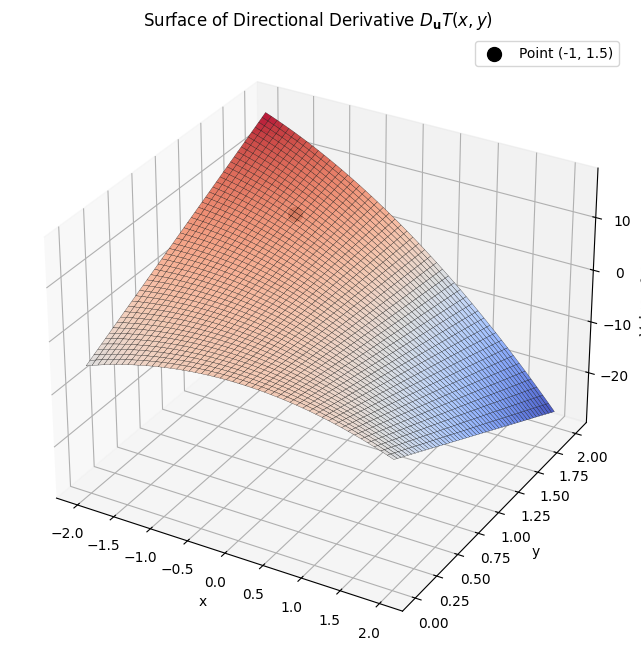

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def solve_directional_derivative():
    # 1. Define Symbols and Function
    x, y = sp.symbols('x y')
    
    # INTERPRETATION: T(x,y) = xy/2 + 3 based on text artifacts
    # You can change this line if the function is different (e.g., x**2 * y**3)
    T = 3 * x**2 * y

    # 2. Compute Gradient and Direction
    # Gradient Vector
    grad_T = sp.Matrix([sp.diff(T, x), sp.diff(T, y)])
    
    # Point and Direction
    P_val = (-1, 1.5)     # Point (x, y)
    v_vec = sp.Matrix([-1, -0.5]) # Direction vector
    
    # Unit Vector u = v / |v|
    u_vec = v_vec / v_vec.norm()
    
    # Directional Derivative Formula: Dot product of Grad and u
    # D_u T(x,y) as a symbolic function
    dir_deriv_sym = grad_T.dot(u_vec)
    
    # Evaluate at the specific point P
    grad_at_P = grad_T.subs({x: P_val[0], y: P_val[1]})
    dd_at_P = dir_deriv_sym.subs({x: P_val[0], y: P_val[1]})
    
    print(f"--- Analytical Results ---")
    print(f"Gradient at {P_val}: {np.array(grad_at_P).astype(float).flatten()}")
    print(f"Directional Derivative at {P_val}: {float(dd_at_P):.4f}")

    # 3. Visualization
    # We will plot the value of the Directional Derivative over the surface
    
    # Create numeric function for D_u T(x,y)
    f_dd = sp.lambdify((x, y), dir_deriv_sym, modules='numpy')
    
    # Setup Grid (-2 <= x <= 2, 0 <= y <= 2)
    x_vals = np.linspace(-2, 2, 50)
    y_vals = np.linspace(0, 2, 50)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Calculate Z values (The Directional Derivative Value)
    Z = f_dd(X, Y)
    
    # Plotting
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot Surface
    ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, edgecolor='k', linewidth=0.2)
    
    # Mark the specific point P(-1, 1.5)
    z_point = float(dd_at_P)
    ax.scatter(P_val[0], P_val[1], z_point, color='black', s=100, label=f'Point {P_val}', zorder=10)
    
    # Labels
    ax.set_title(r"Surface of Directional Derivative $D_{\mathbf{u}}T(x,y)$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel(r"Value of $D_{\mathbf{u}}T$")
    # fig.colorbar(surf, shrink=0.5, aspect=10, label="Directional Derivative Magnitude")
    ax.legend()
    
    plt.show()

if __name__ == "__main__":
    solve_directional_derivative()

## 4b

Gradient at (-20, 5): [ 0.8 -0.4]
(i) Rate West: -0.8 (Descend)
(ii) Rate Northeast: 0.2828 (Ascend)
(iii) Level Direction: 63.43 degrees (North of East)


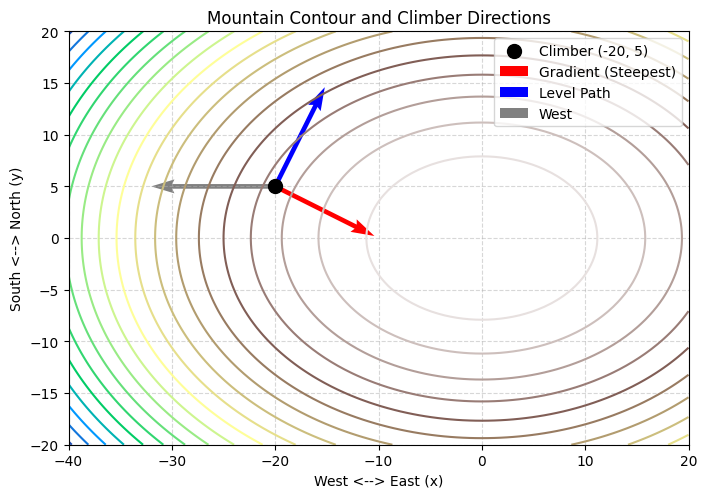

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def solve_mountain_climber():
    # 1. Define Symbols
    x, y = sp.symbols('x y')
    z = 2000 - 0.02*x**2 - 0.04*y**2
    
    # 2. Compute Gradient
    grad_z = sp.Matrix([sp.diff(z, x), sp.diff(z, y)])
    
    # 3. Evaluate at P(-20, 5)
    P = (-20, 5)
    grad_at_P = grad_z.subs({x: P[0], y: P[1]})
    grad_vec = np.array(grad_at_P).astype(float).flatten()
    
    print(f"Gradient at {P}: {grad_vec}")
    
    # --- Part (i) West ---
    u_west = np.array([-1, 0])
    rate_west = np.dot(grad_vec, u_west)
    print(f"(i) Rate West: {rate_west} ({'Ascend' if rate_west > 0 else 'Descend'})")

    # --- Part (ii) Northeast ---
    v_ne = np.array([1, 1])
    u_ne = v_ne / np.linalg.norm(v_ne)
    rate_ne = np.dot(grad_vec, u_ne)
    print(f"(ii) Rate Northeast: {rate_ne:.4f} ({'Ascend' if rate_ne > 0 else 'Descend'})")
    
    # --- Part (iii) Level Path ---
    dir_level = np.array([0.4, 0.8])
    angle_rad = np.arctan2(dir_level[1], dir_level[0])
    angle_deg = np.degrees(angle_rad)
    print(f"(iii) Level Direction: {angle_deg:.2f} degrees (North of East)")

    # 4. Visualization
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Create Contour Plot
    x_range = np.linspace(-40, 20, 100)
    y_range = np.linspace(-20, 20, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = 2000 - 0.02*X**2 - 0.04*Y**2
    
    ax.contour(X, Y, Z, levels=20, cmap='terrain')
    # ax.clabel(contour, inline=True, fontsize=8)
    
    # Plot Climber Position
    ax.scatter(P[0], P[1], color='black', s=100, label='Climber (-20, 5)', zorder=5)
    
    # Plot Gradient (Steepest Ascent)
    ax.quiver(P[0], P[1], grad_vec[0], grad_vec[1], color='red', scale=5, label='Gradient (Steepest)')
    
    # Plot Level Path Direction (Perpendicular)
    ax.quiver(P[0], P[1], dir_level[0], dir_level[1], color='blue', scale=5, label='Level Path')
    
    # Plot West Direction
    # FIX: Removed linestyle='--' to prevent crash
    ax.quiver(P[0], P[1], -1, 0, color='gray', scale=5, label='West')
    
    ax.set_title("Mountain Contour and Climber Directions")
    ax.set_xlabel("West <--> East (x)")
    ax.set_ylabel("South <--> North (y)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    ax.set_aspect('equal')
    
    plt.show()

if __name__ == "__main__":
    solve_mountain_climber()

## 5a

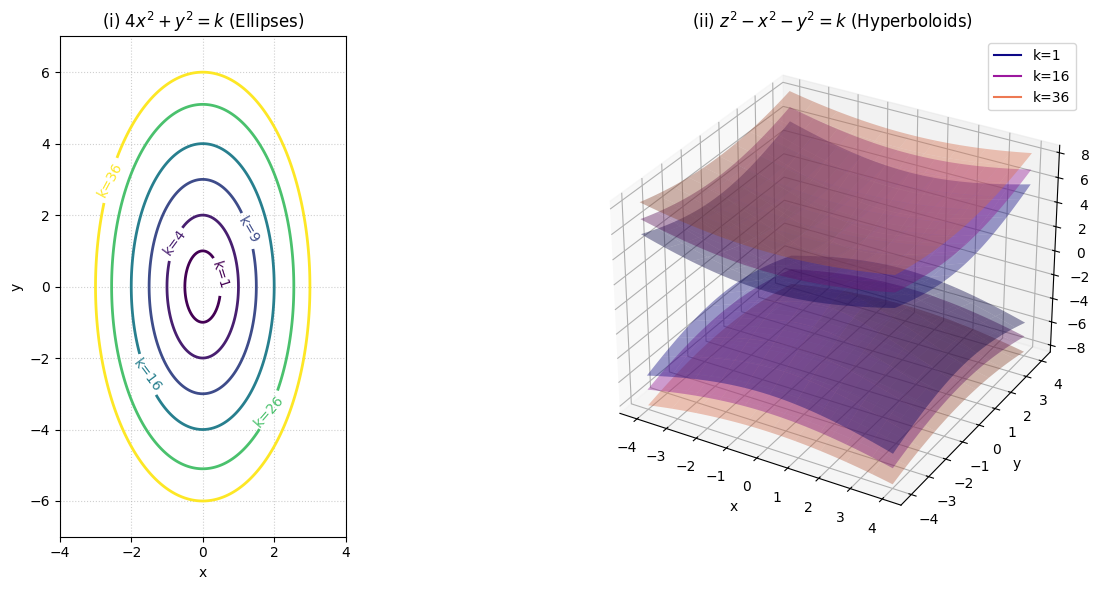

In [9]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def sketch_contours():
    # Define the levels provided in the prompt
    # Note: 26 is likely a typo for 25, but we will use 26 as requested.
    k_levels = [1, 4, 9, 16, 26, 36]
    
    # ==========================================
    # Plot 1: 2D Contour Plot for f(x,y) = 4x^2 + y^2
    # ==========================================
    fig = plt.figure(figsize=(14, 6))
    
    # Subplot 1 (2D)
    ax1 = fig.add_subplot(1, 2, 1)
    
    x = np.linspace(-4, 4, 200)
    y = np.linspace(-7, 7, 200)
    X, Y = np.meshgrid(x, y)
    Z1 = 4*X**2 + Y**2
    
    # Plot contours
    CS = ax1.contour(X, Y, Z1, levels=k_levels, cmap='viridis', linewidths=2)
    ax1.clabel(CS, inline=True, fontsize=10, fmt='k=%d')
    
    ax1.set_title(r"(i) $4x^2 + y^2 = k$ (Ellipses)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_aspect('equal')

    # ==========================================
    # Plot 2: 3D Level Surfaces for f(x,y,z) = z^2 - x^2 - y^2
    # ==========================================
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    
    # Grid for x, y
    x_3d = np.linspace(-4, 4, 50)
    y_3d = np.linspace(-4, 4, 50)
    X3, Y3 = np.meshgrid(x_3d, y_3d)
    
    # We will plot surfaces for a subset of k to avoid overcrowding
    # Plotting k=1 (Inner) and k=36 (Outer)
    subset_k = [1, 16, 36] 
    
    cmap = plt.cm.plasma
    
    for i, k in enumerate(subset_k):
        # z^2 - x^2 - y^2 = k  =>  z = sqrt(x^2 + y^2 + k)
        # We plot both positive and negative sheets
        Z3_pos = np.sqrt(X3**2 + Y3**2 + k)
        Z3_neg = -np.sqrt(X3**2 + Y3**2 + k)
        
        # Determine color based on k
        color = cmap(i / len(subset_k))
        
        ax2.plot_surface(X3, Y3, Z3_pos, color=color, alpha=0.4, rstride=5, cstride=5)
        ax2.plot_surface(X3, Y3, Z3_neg, color=color, alpha=0.4, rstride=5, cstride=5)
        
        # Add a fake line for legend
        ax2.plot([], [], [], color=color, label=f'k={k}')

    ax2.set_title(r"(ii) $z^2 - x^2 - y^2 = k$ (Hyperboloids)")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("z")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    sketch_contours()

## 5b

Visualizing 3D plots. Rotate the figures with your mouse to explore.


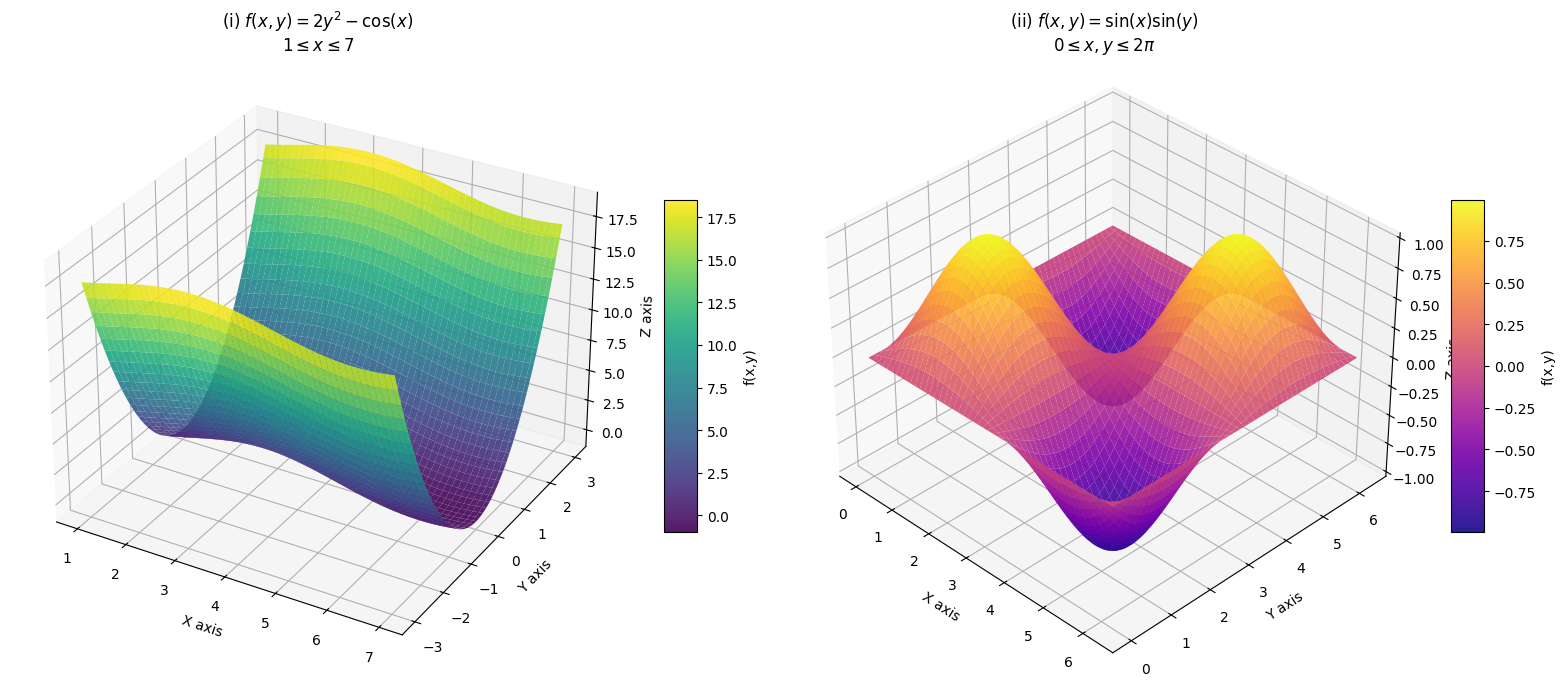

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_three_dimensional_figures():
    """
    Plots two 3D surfaces side-by-side.
    """
    fig = plt.figure(figsize=(16, 7))
    
    # =================================================================
    # Plot (i): f(x, y) = 2y^2 - cos(x)
    # =================================================================
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    x1_vals = np.linspace(1, 7, 150)
    y1_vals = np.linspace(-3, 3, 150) 
    X1, Y1 = np.meshgrid(x1_vals, y1_vals)
    Z1 = 2 * Y1**2 - np.cos(X1)

    surf1 = ax1.plot_surface(X1, Y1, Z1, cmap=cm.viridis, 
                             linewidth=0, antialiased=True, alpha=0.9)

    # FIX: Changed \le to \leq
    ax1.set_title(r'(i) $f(x,y) = 2y^2 - \cos(x)$' + '\n' + r'$1 \leq x \leq 7$')
    ax1.set_xlabel('X axis')
    ax1.set_ylabel('Y axis')
    ax1.set_zlabel('Z axis')
    
    ax1.view_init(elev=30, azim=-60)
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='f(x,y)')


    # =================================================================
    # Plot (ii): f(x, y) = sin(x)sin(y)
    # =================================================================
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    x2_vals = np.linspace(0, 2*np.pi, 150)
    y2_vals = np.linspace(0, 2*np.pi, 150)
    X2, Y2 = np.meshgrid(x2_vals, y2_vals)
    Z2 = np.sin(X2) * np.sin(Y2)

    surf2 = ax2.plot_surface(X2, Y2, Z2, cmap=cm.plasma, 
                             linewidth=0, antialiased=True, alpha=0.9)

    # FIX: Changed \le to \leq
    ax2.set_title(r'(ii) $f(x,y) = \sin(x)\sin(y)$' + '\n' + r'$0 \leq x, y \leq 2\pi$')
    ax2.set_xlabel('X axis')
    ax2.set_ylabel('Y axis')
    ax2.set_zlabel('Z axis')

    ax2.view_init(elev=35, azim=-45)
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='f(x,y)')

    plt.tight_layout()
    print("Visualizing 3D plots. Rotate the figures with your mouse to explore.")
    plt.show()

if __name__ == "__main__":
    plot_three_dimensional_figures()

## 5c

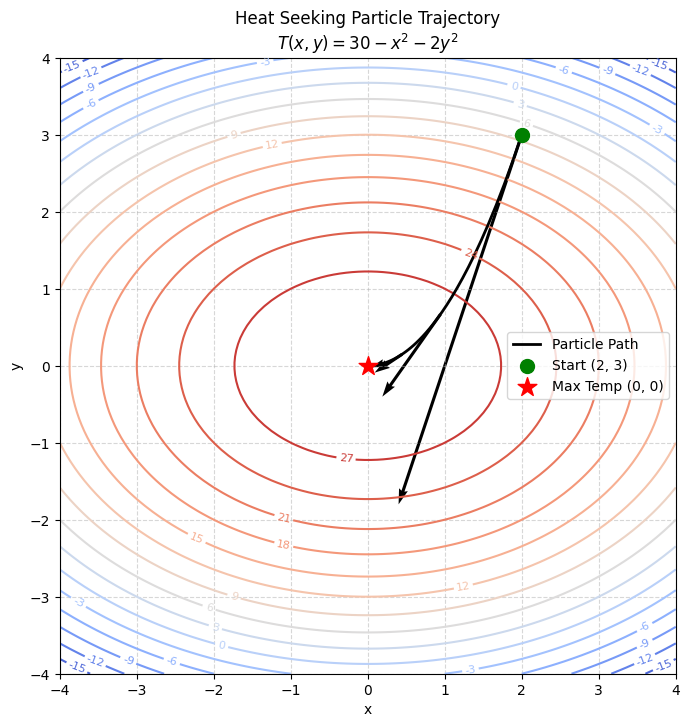

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def solve_heat_particle():
    # 1. Setup the Grid
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(x, y)
    
    # 2. Temperature Function
    T = 30 - X**2 - 2*Y**2
    
    # 3. Particle Trajectory (Parametric)
    # We simulate time t from 0 to 2 (particle moves quickly to the center)
    t = np.linspace(0, 3, 100)
    path_x = 2 * np.exp(-2*t)
    path_y = 3 * np.exp(-4*t)
    
    # 4. Visualization
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Contour Plot (Temperature levels)
    # We use coolwarm so Red = Hot (High T), Blue = Cold (Low T)
    contours = ax.contour(X, Y, T, levels=15, cmap='coolwarm')
    ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')
    
    # Plot the Trajectory
    ax.plot(path_x, path_y, color='black', linewidth=2, label='Particle Path')
    
    # Arrows to show direction (Quiver)
    # We take a few points along the path to draw arrows
    arrow_t = np.linspace(0, 1.5, 5)
    arrow_x = 2 * np.exp(-2*arrow_t)
    arrow_y = 3 * np.exp(-4*arrow_t)
    # Velocity vectors (Gradient direction: -2x, -4y)
    U = -2 * arrow_x
    V = -4 * arrow_y
    ax.quiver(arrow_x, arrow_y, U, V, color='black', scale=20, width=0.005)

    # Mark Start and End
    ax.scatter(2, 3, color='green', s=100, label='Start (2, 3)', zorder=5)
    ax.scatter(0, 0, color='red', marker='*', s=200, label='Max Temp (0, 0)', zorder=5)
    
    # Formatting
    ax.set_title("Heat Seeking Particle Trajectory\n$T(x,y) = 30 - x^2 - 2y^2$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal')
    
    plt.show()

if __name__ == "__main__":
    solve_heat_particle()

## 6a

--- Function (i) Critical Points ---
Point {x: -1, y: -1}: Max (D=128)
Point {x: 0, y: 0}: Saddle (D=-16)
Point {x: 1, y: 1}: Max (D=128)

--- Function (ii) Critical Points ---
Point {x: 0, y: 0}: Saddle (D=-4)


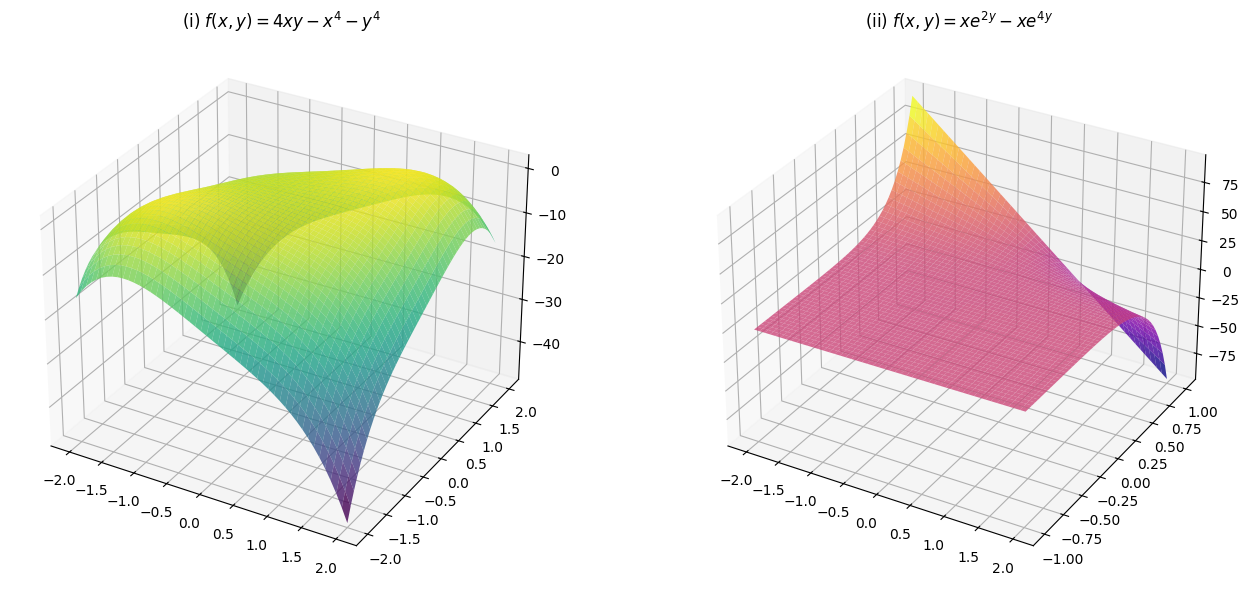

In [14]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot():
    x, y = sp.symbols('x y')
    
    # --- Function 1 ---
    f1 = 4*x*y - x**4 - y**4
    
    # --- Function 2 (Interpreted) ---
    # Adjust this line if the specific coefficients in your text differ
    f2 = x * sp.exp(2*y) - x * sp.exp(4*y) 

    # Helper to find Critical Points
    def solve_critical(f):
        grad = [sp.diff(f, var) for var in (x, y)]
        sols = sp.solve(grad, (x, y), dict=True)
        return sols

    print("--- Function (i) Critical Points ---")
    cps1 = solve_critical(f1)
    for p in cps1:
        # Filter for real numbers only
        if p[x].is_real and p[y].is_real:
            # Hessian Determinant
            fxx = sp.diff(f1, x, x).subs(p)
            fyy = sp.diff(f1, y, y).subs(p)
            fxy = sp.diff(f1, x, y).subs(p)
            D = fxx*fyy - fxy**2
            Type = "Saddle" if D < 0 else "Max" if fxx < 0 else "Min"
            print(f"Point {p}: {Type} (D={D})")

    print("\n--- Function (ii) Critical Points ---")
    cps2 = solve_critical(f2)
    for p in cps2:
        if p[x].is_real and p[y].is_real:
            fxx = sp.diff(f2, x, x).subs(p)
            fyy = sp.diff(f2, y, y).subs(p)
            fxy = sp.diff(f2, x, y).subs(p)
            D = fxx*fyy - fxy**2
            Type = "Saddle" if D < 0 else "Max" if fxx < 0 else "Min"
            print(f"Point {p}: {Type} (D={D})")

    # --- Plotting ---
    fig = plt.figure(figsize=(14, 6))

    # Plot 1
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    x_val = np.linspace(-2, 2, 50)
    y_val = np.linspace(-2, 2, 50)
    X, Y = np.meshgrid(x_val, y_val)
    Z1 = 4*X*Y - X**4 - Y**4
    ax1.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.8)
    ax1.set_title(r'(i) $f(x,y) = 4xy - x^4 - y^4$')
    
    # Plot 2
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    x_val2 = np.linspace(-2, 2, 50)
    y_val2 = np.linspace(-1, 1, 50) # y range where exp is manageable
    X2, Y2 = np.meshgrid(x_val2, y_val2)
    Z2 = X2 * np.exp(2*Y2) - X2 * np.exp(4*Y2)
    ax2.plot_surface(X2, Y2, Z2, cmap='plasma', alpha=0.8)
    ax2.set_title(r'(ii) $f(x,y) = x e^{2y} - x e^{4y}$')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_and_plot()

## 6b

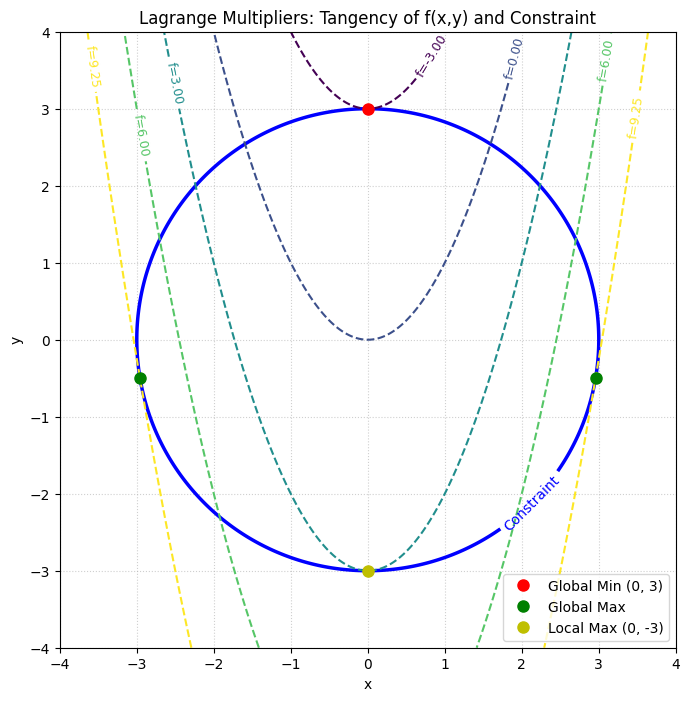

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def solve_lagrange_circles():
    # 1. Setup Grid
    x = np.linspace(-4, 4, 400)
    y = np.linspace(-4, 4, 400)
    X, Y = np.meshgrid(x, y)
    
    # 2. Define Functions
    # Objective function: f(x,y) = x^2 - y
    Z = X**2 - Y
    # Constraint circle: x^2 + y^2 = 9
    Constraint = X**2 + Y**2
    
    # 3. Setup Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot Constraint (The Circle)
    circle = ax.contour(X, Y, Constraint, levels=[9], colors='blue', linewidths=2.5)
    ax.clabel(circle, fmt='Constraint', inline=True, fontsize=10)
    
    # Plot Level Curves of f(x,y) (The Parabolas)
    # We plot levels corresponding to our found values: -3, 3, 9.25
    levels = [-3, 0, 3, 6, 9.25]
    contours = ax.contour(X, Y, Z, levels=levels, cmap='viridis', linestyles='dashed')
    ax.clabel(contours, inline=True, fontsize=9, fmt='f=%1.2f')
    
    # 4. Mark Critical Points
    # P1: Min at (0, 3)
    ax.plot(0, 3, 'ro', markersize=8, label='Global Min (0, 3)')
    
    # P3, P4: Max at (+-sqrt(8.75), -0.5)
    x_max = np.sqrt(8.75)
    ax.plot(x_max, -0.5, 'go', markersize=8, label='Global Max')
    ax.plot(-x_max, -0.5, 'go', markersize=8)
    
    # P2: Local Max at (0, -3)
    ax.plot(0, -3, 'yo', markersize=8, label='Local Max (0, -3)')

    # Formatting
    ax.set_title("Lagrange Multipliers: Tangency of f(x,y) and Constraint")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_aspect('equal')
    
    plt.show()

if __name__ == "__main__":
    solve_lagrange_circles()

## 6c


--- Results for (i) $f(x,y) = xe^y$ at $(1,0)$ ---
T1 = x + y
T2 = x*y + x + y**2/2
T3 = x*y**2/2 + x*y + x + y**3/6

--- Results for (ii) $f(x,y) = e^x \sin(y)$ at $(1, \pi/2)$ ---
T1 = E*x
T2 = E*x**2/2 - E*y**2/2 + E*pi*y/2 - E*pi**2/8 + E/2
T3 = E*x**3/6 - E*x*y**2/2 + E*pi*x*y/2 - E*pi**2*x/8 + E*x/2 + E/3

--- Results for (iii) $f(x,y) = e^x \cos(y)$ at $(0,0)$ ---
T1 = x + 1
T2 = x**2/2 + x - y**2/2 + 1
T3 = x**3/6 + x**2/2 - x*y**2/2 + x - y**2/2 + 1


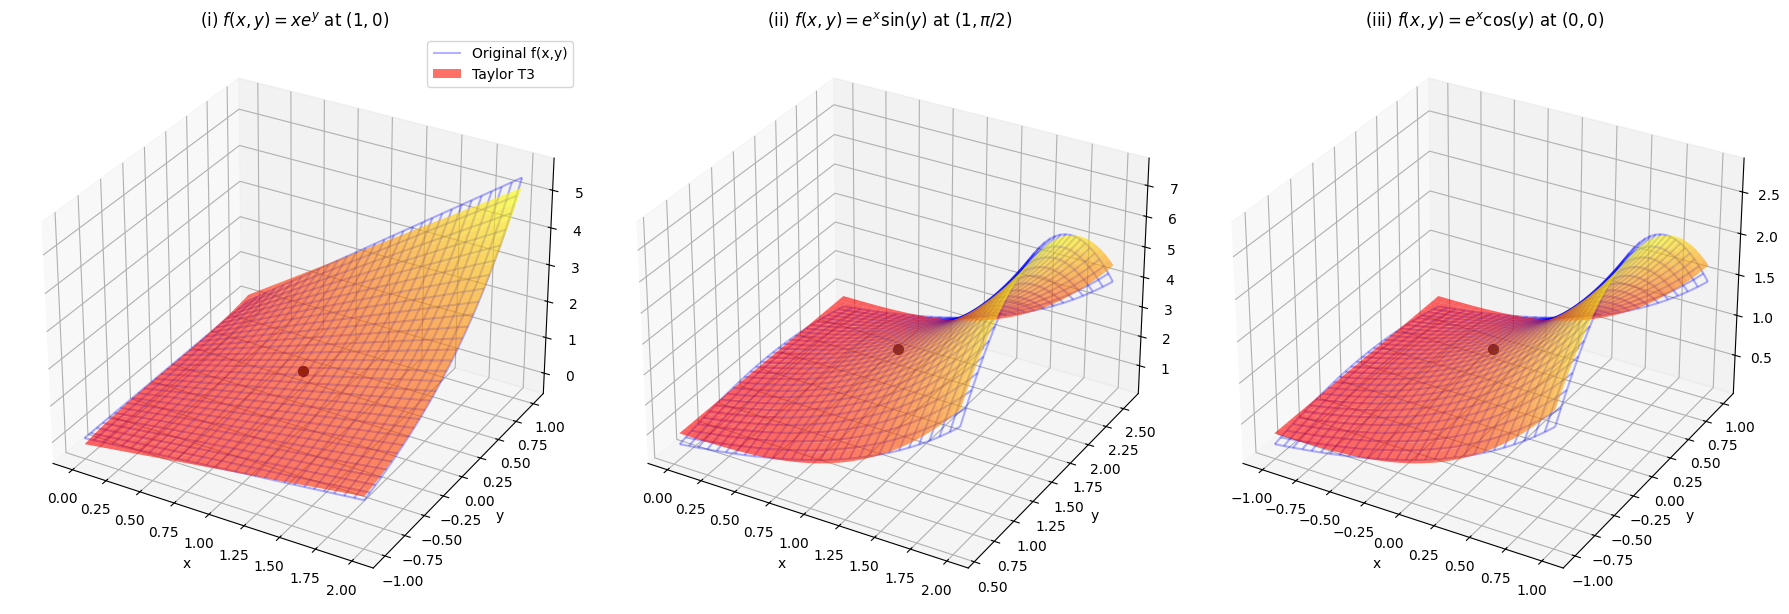

In [16]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def solve_and_plot_taylor():
    x, y = sp.symbols('x y')

    # Define the 3 Problems: (Function, x0, y0, Label)
    problems = [
        (x * sp.exp(y), 1, 0, r"(i) $f(x,y) = xe^y$ at $(1,0)$"),
        (sp.exp(x) * sp.sin(y), 1, sp.pi/2, r"(ii) $f(x,y) = e^x \sin(y)$ at $(1, \pi/2)$"),
        (sp.exp(x) * sp.cos(y), 0, 0, r"(iii) $f(x,y) = e^x \cos(y)$ at $(0,0)$")
    ]

    # Helper to compute Taylor Series
    def get_taylor_polynomials(f, x0, y0):
        # Substitute point to get constants
        subs_point = {x: x0, y: y0}
        
        # 0th Order
        f_val = f.subs(subs_point)
        
        # 1st Order Partials
        fx = sp.diff(f, x).subs(subs_point)
        fy = sp.diff(f, y).subs(subs_point)
        
        # 2nd Order Partials
        fxx = sp.diff(f, x, x).subs(subs_point)
        fxy = sp.diff(f, x, y).subs(subs_point)
        fyy = sp.diff(f, y, y).subs(subs_point)
        
        # 3rd Order Partials
        fxxx = sp.diff(f, x, x, x).subs(subs_point)
        fxxy = sp.diff(f, x, x, y).subs(subs_point)
        fxyy = sp.diff(f, x, y, y).subs(subs_point)
        fyyy = sp.diff(f, y, y, y).subs(subs_point)

        # Deltas
        dx = (x - x0)
        dy = (y - y0)

        # Construct Polynomials
        T1 = f_val + fx*dx + fy*dy
        
        T2 = T1 + sp.Rational(1,2)*(fxx*dx**2 + 2*fxy*dx*dy + fyy*dy**2)
        
        T3 = T2 + sp.Rational(1,6)*(fxxx*dx**3 + 3*fxxy*dx**2*dy + 3*fxyy*dx*dy**2 + fyyy*dy**3)
        
        return T1, T2, T3

    # Visualization Loop
    fig = plt.figure(figsize=(18, 6))

    for idx, (func, x0, y0, title) in enumerate(problems):
        # 1. Compute Polynomials
        T1, T2, T3 = get_taylor_polynomials(func, x0, y0)
        
        print(f"\n--- Results for {title} ---")
        print(f"T1 = {sp.expand(T1)}")
        print(f"T2 = {sp.expand(T2)}")
        print(f"T3 = {sp.expand(T3)}")
        
        # 2. Plotting (Original vs T3)
        ax = fig.add_subplot(1, 3, idx+1, projection='3d')
        
        # Create numerical functions
        f_lam = sp.lambdify((x, y), func, 'numpy')
        t3_lam = sp.lambdify((x, y), T3, 'numpy')
        
        # Determine range centered on expansion point
        # We assume a small window to show convergence
        cx, cy = float(x0), float(y0)
        range_span = 1.0
        x_vals = np.linspace(cx - range_span, cx + range_span, 30)
        y_vals = np.linspace(cy - range_span, cy + range_span, 30)
        X, Y = np.meshgrid(x_vals, y_vals)
        
        Z_orig = f_lam(X, Y)
        Z_poly = t3_lam(X, Y)
        
        # Plot Original (Wireframe)
        ax.plot_wireframe(X, Y, Z_orig, color='blue', alpha=0.3, label='Original f(x,y)')
        
        # Plot Taylor T3 (Surface)
        surf = ax.plot_surface(X, Y, Z_poly, cmap=cm.autumn, alpha=0.6, label='Taylor T3')
        
        # Mark the center point
        ax.scatter(cx, cy, f_lam(cx, cy), color='black', s=50, zorder=10)
        
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        
        # Helper to avoid legend clutter
        if idx == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    solve_and_plot_taylor()

## 7a

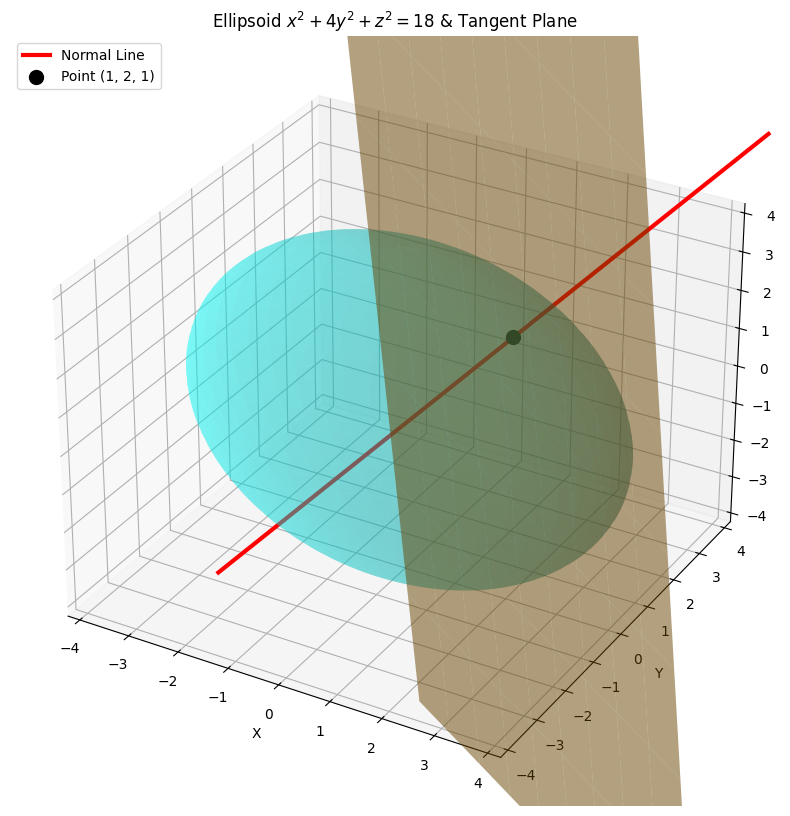

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_ellipsoid_system():
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the Ellipsoid: x^2 + 4y^2 + z^2 = 18
    # Parameterization: x = a*sin(u)cos(v), y = b*sin(u)sin(v), z = c*cos(u)
    # a^2 = 18, b^2 = 18/4 = 4.5, c^2 = 18
    a, b, c = np.sqrt(18), np.sqrt(4.5), np.sqrt(18)
    
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones(np.size(u)), np.cos(v))
    
    ax.plot_surface(x, y, z, color='cyan', alpha=0.3, edgecolor='none')

    # 2. Plot the Tangent Plane: x + 8y + z = 18 => z = 18 - x - 8y
    # We create a meshgrid centered around the point (1, 2)
    xx, yy = np.meshgrid(np.linspace(-2, 4, 10), np.linspace(0, 4, 10))
    zz = 18 - xx - 8*yy
    
    ax.plot_surface(xx, yy, zz, color='orange', alpha=0.5)

    # 3. Plot the Normal Line: x=1+t, y=2+8t, z=1+t
    t = np.linspace(-1, 1, 100)
    line_x = 1 + t
    line_y = 2 + 8*t
    line_z = 1 + t
    
    ax.plot(line_x, line_y, line_z, color='red', linewidth=3, label='Normal Line')
    
    # 4. Mark the Point (1, 2, 1)
    ax.scatter(1, 2, 1, color='black', s=100, label='Point (1, 2, 1)', zorder=10)

    # Formatting
    ax.set_title(r'Ellipsoid $x^2 + 4y^2 + z^2 = 18$ & Tangent Plane')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Set equal aspect ratio for realistic distortion
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (y.max()+y.min()) * 0.5
    mid_z = (z.max()+z.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.legend()
    plt.show()

if __name__ == "__main__":
    visualize_ellipsoid_system()

## 7b

Point (x, y, z)                | Temperature
---------------------------------------------
( 1.33, -1.33, -1.33)       | 642.67
(-1.33, -1.33, -1.33)       | 642.67
( 0.00,  4.00,  0.00)       | 600.00
( 0.00, -2.00, -1.73)       | 641.57
( 0.00, -2.00,  1.73)       | 558.43


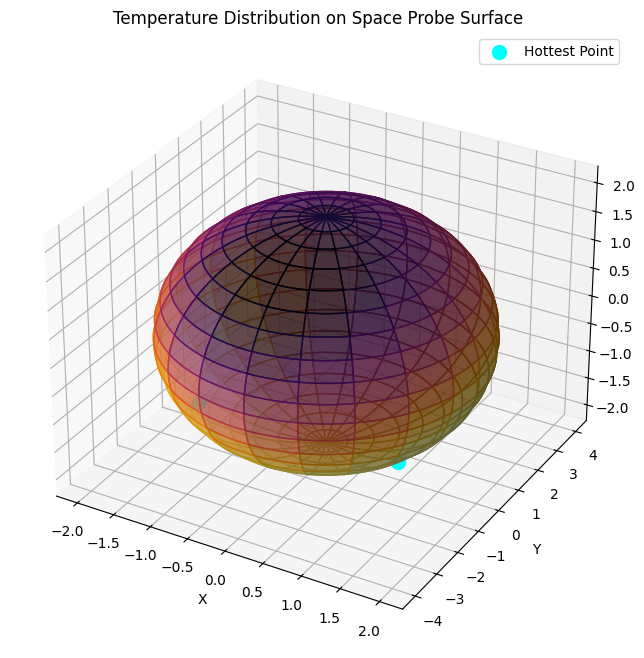

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def solve_space_probe_heat():
    # 1. Define the points found analytically
    points = [
        (4/3, -4/3, -4/3, "Max"),
        (-4/3, -4/3, -4/3, "Max"),
        (0, 4, 0, "Local Min"),
        (0, -2, -np.sqrt(3), "High"),
        (0, -2, np.sqrt(3), "Low")
    ]
    
    # 2. Function to calculate Temp
    def get_T(x, y, z):
        return 8*x**2 + 4*y*z - 16*z + 600

    print(f"{'Point (x, y, z)':<30} | {'Temperature'}")
    print("-" * 45)
    for p in points:
        x, y, z, label = p
        T = get_T(x, y, z)
        print(f"({x:5.2f}, {y:5.2f}, {z:5.2f})       | {T:.2f}")

    # 3. Visualization
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create Ellipsoid Mesh
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    # 4x^2 + y^2 + 4z^2 = 16 => x^2/4 + y^2/16 + z^2/4 = 1
    # a=2, b=4, c=2
    x = 2 * np.outer(np.cos(u), np.sin(v))
    y = 4 * np.outer(np.sin(u), np.sin(v))
    z = 2 * np.outer(np.ones(np.size(u)), np.cos(v))
    
    # Map Temperature to Color
    T_vals = 8*x**2 + 4*y*z - 16*z + 600
    # Normalize for colormap
    norm_T = (T_vals - T_vals.min()) / (T_vals.max() - T_vals.min())
    
    ax.plot_surface(x, y, z, facecolors=plt.cm.inferno(norm_T), rstride=5, cstride=5, alpha=0.6)
    
    # Mark Max Points
    ax.scatter(4/3, -4/3, -4/3, color='cyan', s=100, label='Hottest Point', zorder=10)
    ax.scatter(-4/3, -4/3, -4/3, color='cyan', s=100, zorder=10)
    
    ax.set_title("Temperature Distribution on Space Probe Surface")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    
    plt.show()

if __name__ == "__main__":
    solve_space_probe_heat()

## 8a

In [19]:
import sympy as sp

def solve_a():
    x, y, z = sp.symbols('x y z')
    
    print("--- Part (a) ---")
    
    # (i) Triple Integral
    # Limits: z from 3 to 4-x^2-y^2, y from 0 to 1-x^2, x from 0 to 1
    integrand_i = x * sp.exp(-y) * sp.cos(z)
    integral_i = sp.integrate(integrand_i, (z, 3, 4 - x**2 - y**2))
    integral_i = sp.integrate(integral_i, (y, 0, 1 - x**2))
    integral_i = sp.integrate(integral_i, (x, 0, 1))
    
    print(f"(i) Result: {integral_i}")
    # Note: This integral might not have a clean closed-form solution symbolically. 
    # If it takes too long or returns an Unevaluated integral, numerical methods are usually preferred for such complex bounds.

    # (ii) Double Integral
    # Limits: y from 0 to 1, x from 0 to 1
    integrand_ii = (x * y) / sp.sqrt(x**2 + y**2 + 1)
    integral_ii = sp.integrate(integrand_ii, (y, 0, 1))
    final_ii = sp.integrate(integral_ii, (x, 0, 1))
    
    print(f"(ii) Result: {final_ii}")

if __name__ == "__main__":
    solve_a()

--- Part (a) ---
(i) Result: -Integral(x*Integral(exp(-y)*sin(x**2 + y**2 - 4), (y, 0, 1 - x**2)), (x, 0, 1)) - Integral(x*Integral(exp(-y)*sin(3), (y, 0, 1 - x**2)), (x, 0, 1))
(ii) Result: -4*sqrt(2)/3 + 1/3 + sqrt(3)


## 8b

In [20]:
import sympy as sp

def solve_b():
    x, y = sp.symbols('x y')
    
    print("\n--- Part (b) ---")
    
    # Surface equation z = sqrt(4 - x^2)
    z = sp.sqrt(4 - x**2)
    
    # Partial derivatives
    dz_dx = sp.diff(z, x)
    dz_dy = sp.diff(z, y) # This will be 0
    
    # Surface area integrand: sqrt(1 + (dz/dx)^2 + (dz/dy)^2)
    integrand = sp.sqrt(1 + dz_dx**2 + dz_dy**2)
    
    # Region R: 0 <= x <= 1, 0 <= y <= 4
    # We simplify the integrand first to help sympy
    integrand = sp.simplify(integrand)
    
    area = sp.integrate(integrand, (y, 0, 4), (x, 0, 1))
    
    print(f"Surface Area: {area}")

if __name__ == "__main__":
    solve_b()


--- Part (b) ---
Surface Area: 8*Integral(sqrt(-1/(x**2 - 4)), (x, 0, 1))


## 8c

In [21]:
import sympy as sp

def solve_c():
    r, theta = sp.symbols('r theta')
    
    print("\n--- Part (c) ---")
    
    # Function z = 4 - x^2 - y^2 converted to polar: 4 - r^2
    z_polar = 4 - r**2
    
    # The cylinder (x-1)^2 + y^2 = 1 is a circle centered at (1,0) radius 1.
    # Polar equation: r = 2*cos(theta)
    # Bounds for theta: -pi/2 to pi/2 (covers the full circle in the right half-plane)
    
    # Integrand for volume in polar: z * r
    integrand = z_polar * r
    
    # Integrate r from 0 to 2*cos(theta)
    inner_integral = sp.integrate(integrand, (r, 0, 2 * sp.cos(theta)))
    
    # Integrate theta from -pi/2 to pi/2
    volume = sp.integrate(inner_integral, (theta, -sp.pi/2, sp.pi/2))
    
    print(f"Volume: {volume}")

if __name__ == "__main__":
    solve_c()


--- Part (c) ---
Volume: 5*pi/2


## 8d

In [22]:
import sympy as sp

def solve_d():
    r, theta = sp.symbols('r theta')
    
    print("\n--- Part (d) ---")
    
    # Thickness function T(r)
    thickness = 1 - r**2 / 4
    
    # Region is a circle of radius 2
    # Area of the base circle = pi * radius^2 = 4*pi
    radius = 2
    area_base = sp.pi * radius**2
    
    # To find total volume (mass), integrate Thickness * dA
    # dA in polar is r dr dtheta
    integrand = thickness * r
    
    total_thickness_integrated = sp.integrate(integrand, (r, 0, 2), (theta, 0, 2*sp.pi))
    
    # Average thickness = Total Volume / Base Area
    avg_thickness = total_thickness_integrated / area_base
    
    print(f"Total Integrated Volume: {total_thickness_integrated}")
    print(f"Base Area: {area_base}")
    print(f"Average Thickness: {avg_thickness}")

if __name__ == "__main__":
    solve_d()


--- Part (d) ---
Total Integrated Volume: 2*pi
Base Area: 4*pi
Average Thickness: 1/2


In [1]:
print("hi")

hi


In [2]:
# !git clone https://github.com/rabbidu/ass2.git

Cloning into 'ass2'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 2.75 MiB | 3.95 MiB/s, done.
